# EDA

Disclaimer: this notebook has been written with the aid of [ChatGPT](https://chatgpt.com/share/6a25b40f-d42c-83eb-91cc-48ab869c6785).

## Importing Libraries

In [38]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [39]:
# Setting paths for the data folder and the .csv file
dataFolder = "C:/Users/sKALa/Repos/Semester 2/Dissertation/Albert Skalinski - Dissertation/data"
dataPath = dataFolder + "/cleanData.csv"

# Reading the cleaned data
df = pd.read_csv(dataPath)

# Checking if the data was read correctly
display(df.head())

,name,artist,genre,popularity,releaseDate,releaseYear,releaseMonth,timePeriod,energy,danceability,...,liveness,valence,speechiness,instrumentalness,acousticness,tempo,timeSignature,mode,key,durationMin
0,Die With A Smile,"Lady Gaga, Bruno Mars",pop,100,2024-08-16,2024,8,2020s,0.592,0.521,...,0.122,0.535,0.0304,0.0000,0.3080,157.969,3,0,6,4.19
1,BIRDS OF A FEATHER,Billie Eilish,pop,97,2024-05-17,2024,5,2020s,0.507,0.747,...,0.117,0.438,0.0358,0.0608,0.2000,104.978,4,1,2,3.51
2,That’s So True,Gracie Abrams,pop,93,2024-10-18,2024,10,2020s,0.808,0.554,...,0.159,0.372,0.0368,0.0000,0.2140,108.548,4,1,1,2.77
3,Taste,Sabrina Carpenter,pop,81,2024-08-23,2024,8,2020s,0.910,0.670,...,0.304,0.786,0.0634,0.0000,0.0939,112.966,4,0,0,2.62
4,APT.,"ROSÉ, Bruno Mars",pop,98,2024-10-18,2024,10,2020s,0.783,0.777,...,0.355,0.939,0.2600,0.0000,0.0283,149.027,4,0,0,2.83


## Basic Overview

In [40]:
# Basic information on each column
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              4368 non-null   object 
 1   artist            4368 non-null   object 
 2   genre             4368 non-null   object 
 3   popularity        4368 non-null   int64  
 4   releaseDate       4368 non-null   object 
 5   releaseYear       4368 non-null   int64  
 6   releaseMonth      4368 non-null   int64  
 7   timePeriod        4368 non-null   object 
 8   energy            4368 non-null   float64
 9   danceability      4368 non-null   float64
 10  loudness          4368 non-null   float64
 11  liveness          4368 non-null   float64
 12  valence           4368 non-null   float64
 13  speechiness       4368 non-null   float64
 14  instrumentalness  4368 non-null   float64
 15  acousticness      4368 non-null   float64
 16  tempo             4368 non-null   float64


None

In [41]:
# Descriptive statistics for numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
popularity,4368.0,53.105769,19.509811,11.000000,39.00000,53.000000,70.00000,100.000
releaseYear,4368.0,2017.488553,9.921139,1954.000000,2016.00000,2022.000000,2024.00000,2024.000
releaseMonth,4368.0,6.682463,3.377839,1.000000,4.00000,7.000000,10.00000,12.000
energy,4368.0,0.577719,0.250067,0.000202,0.42200,0.626000,0.76900,0.998
danceability,4368.0,0.621836,0.189724,0.058900,0.52475,0.655000,0.75900,0.979
loudness,4368.0,-9.500942,7.338208,-48.069000,-10.60150,-7.300500,-5.37975,1.318
liveness,4368.0,0.167669,0.125042,0.021000,0.09560,0.117000,0.19425,0.979
valence,4368.0,0.475387,0.258628,0.029600,0.26300,0.476000,0.68325,0.987
speechiness,4368.0,0.101408,0.101307,0.021900,0.03850,0.055400,0.11700,0.927
instrumentalness,4368.0,0.214373,0.360552,0.000000,0.00000,0.000118,0.32750,0.991


In [42]:
# Descriptive statistics for categorical columns
display(df.describe(include = "object").T)

,count,unique,top,freq
name,4368,4251,I Miss You,4
artist,4368,3304,Bad Bunny,29
genre,4368,35,electronic,555
releaseDate,4368,1804,2023-10-27,31
timePeriod,4368,6,2020s,2799


## Popularity EDA

In [43]:
# Summary statistics
df["popularity"].describe()

count    4368.000000
mean       53.105769
std        19.509811
min        11.000000
25%        39.000000
50%        53.000000
75%        70.000000
max       100.000000
Name: popularity, dtype: float64

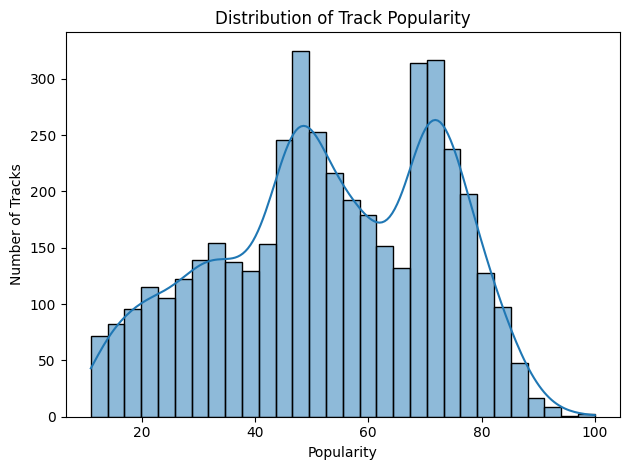

In [44]:
# Histogram
plt.figure()
sns.histplot(data = df, x = "popularity", bins = 30, kde = True)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

The distribution seems to be bimodal, with two significant peaks: the first one around 50, and the second one around 70. There are little tracks that achieved more than 80.

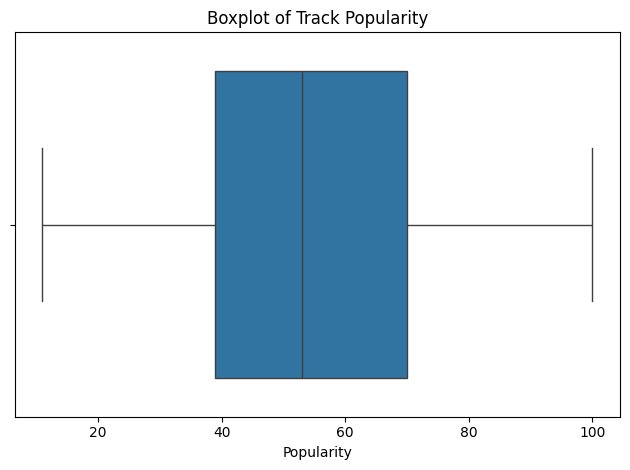

In [45]:
# Boxplot
plt.figure()
sns.boxplot(data = df, x = "popularity")
plt.title("Boxplot of Track Popularity")
plt.xlabel("Popularity")
plt.tight_layout()
plt.show()

Popularity seems to be evenly distributed with the median of ~50.

In [46]:
# Declaring popularity groups
def popularityGroup(score):
    if score < 40:
        return "Low popularity"
    elif score < 70:
        return "Medium popularity"
    else:
        return "High popularity"

df["popularityGroup"] = df["popularity"].apply(popularityGroup)

df["popularityGroup"].value_counts()

popularityGroup
Medium popularity    2093
High popularity      1169
Low popularity       1106
Name: count, dtype: int64

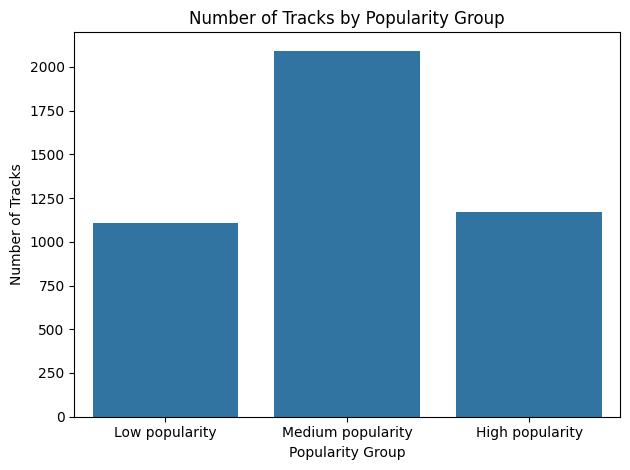

In [47]:
# Countplot for popularity groups
plt.figure()

sns.countplot(data = df, x = "popularityGroup", order = ["Low popularity", "Medium popularity", "High popularity"])

plt.title("Number of Tracks by Popularity Group")
plt.xlabel("Popularity Group")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

Most tracks seem to be intermediately popular (between 40 and 69). There is a similar number of highly and slightly popular tracks (~1000).

## Release Date EDA

In [48]:
# Range
print("Earliest release year:", df["releaseYear"].min())
print("Latest release year:", df["releaseYear"].max())

Earliest release year: 1954
Latest release year: 2024


The oldest track from the set is from 1954, whilst the newest one is from 2024.

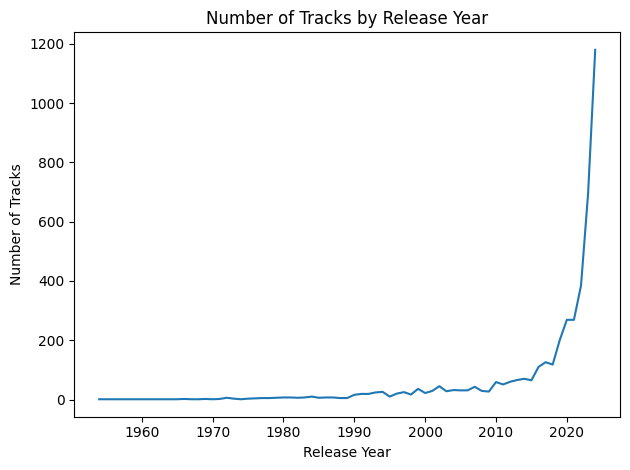

In [49]:
# Number of tracks per year plot
tracksByYear = df["releaseYear"].value_counts().sort_index()

plt.figure()
sns.lineplot(x = tracksByYear.index, y = tracksByYear.values)
plt.title("Number of Tracks by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

Most songs in the dataset are fairly new and were released after 2010.

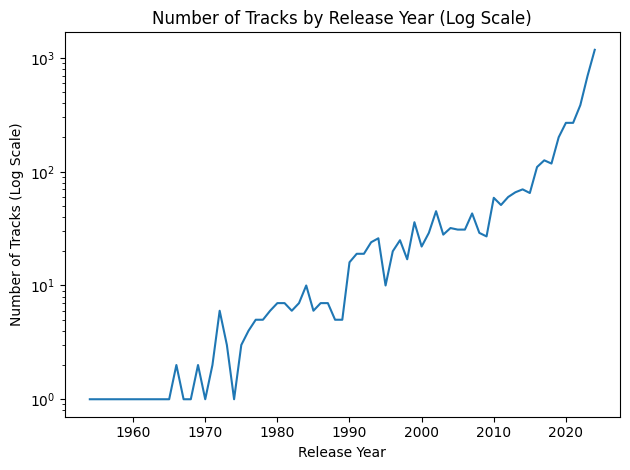

In [50]:
# Same plot with a logarithmic scale on the y-axis
plt.figure()
sns.lineplot(x = tracksByYear.index, y = tracksByYear.values)
plt.yscale("log")
plt.title("Number of Tracks by Release Year (Log Scale)")
plt.xlabel("Release Year")
plt.ylabel("Number of Tracks (Log Scale)")
plt.tight_layout()
plt.show()

The plot shows a positive relation between the number of tracks and the release year. The higher the release year, the more tracks from that year are present in the dataset.

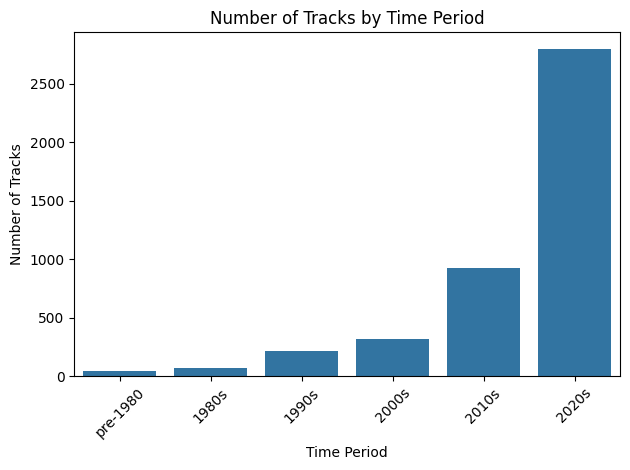

In [51]:
# Number of tracks by time period
timePeriodOrder = ["pre-1980", "1980s", "1990s", "2000s", "2010s", "2020s"]

df["timePeriod"].value_counts().reindex(timePeriodOrder)

plt.figure()
sns.countplot(data = df, x = "timePeriod", order = timePeriodOrder)
plt.title("Number of Tracks by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Tracks")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Majority of tracks came out in 2020s.

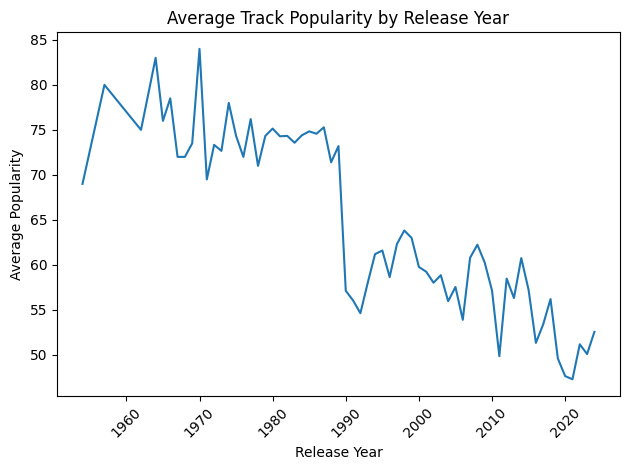

In [52]:
# Average popularity by year
averagePopularityByYear = df.groupby("releaseYear")["popularity"].mean()

plt.figure()
sns.lineplot(x = averagePopularityByYear.index, y = averagePopularityByYear.values)
plt.title("Average Track Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Older songs generally have higher average popularity. People might enjoy the old "classics" more, therefore these songs are being added to different playlists. This also might be caused by the fact that there are far less songs that came out before 2000 compared to the ones that are more recent. Although, one can see that the lowest average here is ~45. So, no year was significantly worse than the others.

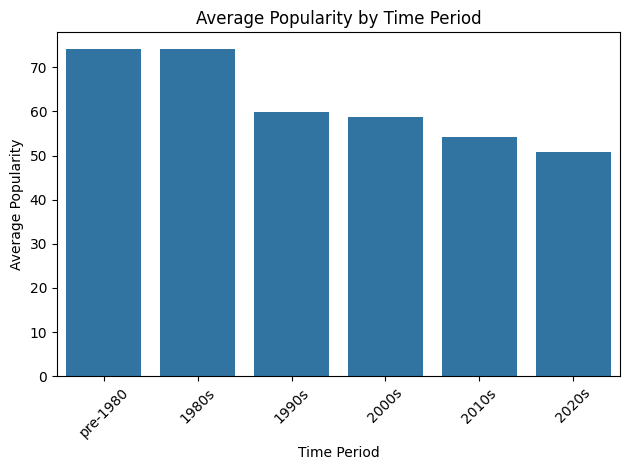

In [53]:
# Average popularity by time period
averagePopularityByPeriod = (df.groupby("timePeriod")["popularity"].mean().reindex(timePeriodOrder))

plt.figure()
sns.barplot(x = averagePopularityByPeriod.index, y = averagePopularityByPeriod.values)
plt.title("Average Popularity by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Popularity")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

It's more visible on the bar chart now, that actually time periods do not differ that much. Older songs still have higher average popularity though.

## Genre EDA

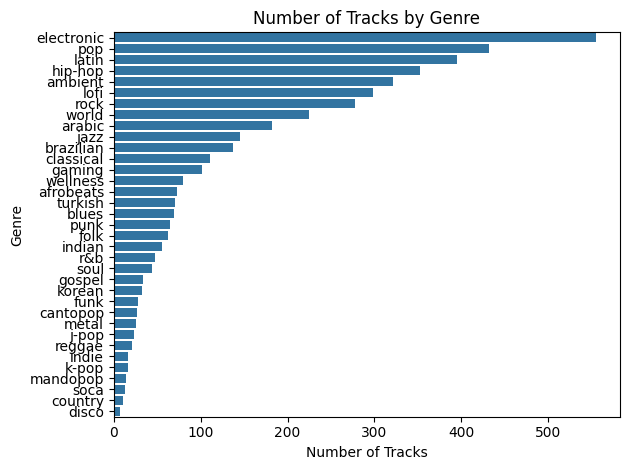

In [54]:
# Number of tracks by genre
plt.figure()
sns.countplot(data = df, y = "genre", order = df["genre"].value_counts().index)
plt.title("Number of Tracks by Genre")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Electronic, pop, latin, hip-hop & ambient occur the most. Disco, country, soca, mandopop & k-pop are occur the least here.

## Correlation Analysis

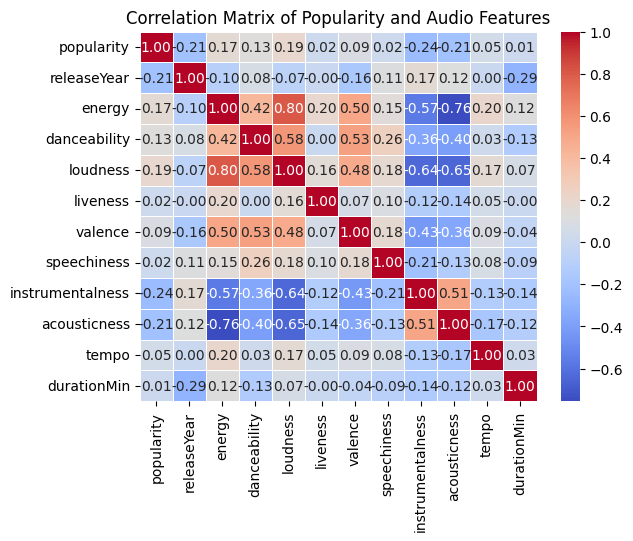

In [55]:
# Creating the correlation matrix
correlationColumns = ["popularity", "releaseYear", "energy", "danceability", "loudness", "liveness", "valence", "speechiness",
                   "instrumentalness", "acousticness", "tempo", "durationMin"]

correlationMatrix = df[correlationColumns].corr()

# Correlation heatmap
plt.figure()
sns.heatmap(correlationMatrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 0.5)
plt.title("Correlation Matrix of Popularity and Audio Features")
# plt.tight_layout()
plt.show()

Variables with strong positive correlations:
- loudness & energy

<br>

Variables with moderate positive correlations:
- danceability & energy
- danceability & loudness
- valence & energy
- valence & danceability
- valence & loudness
- acousticness & instrumentalness

<br>

Variables with strong negative correlations:
- acousticness & energy

<br>

Variables with moderate negative correlations:
- energy & instrumentalness
- loudness & instrumentalness
- loudness & acousticness

In terms of popularity, it negatively and semi-moderately correlates with release year, instrumentalness and acousticness.

## Audio Features vs Popularity

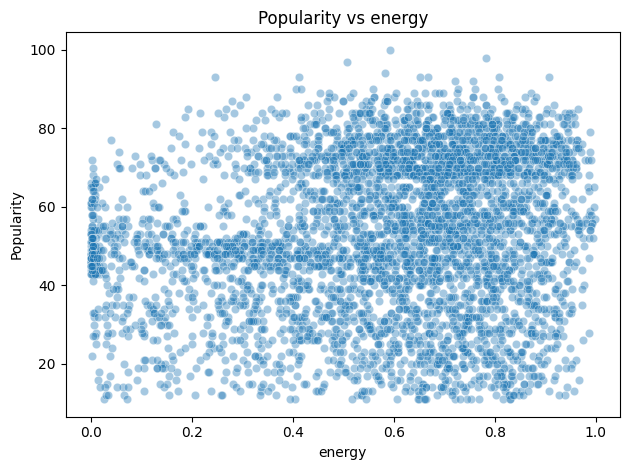

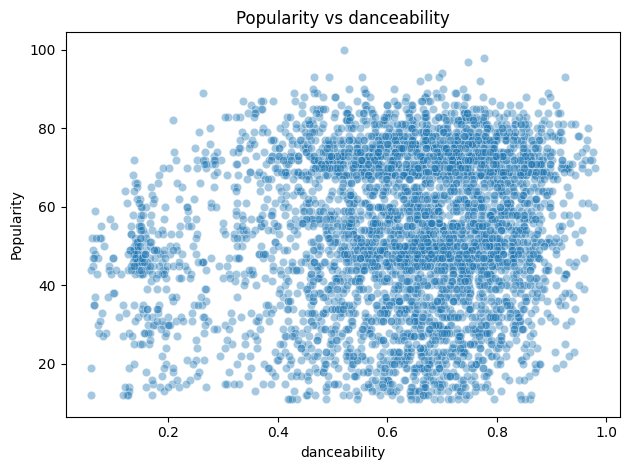

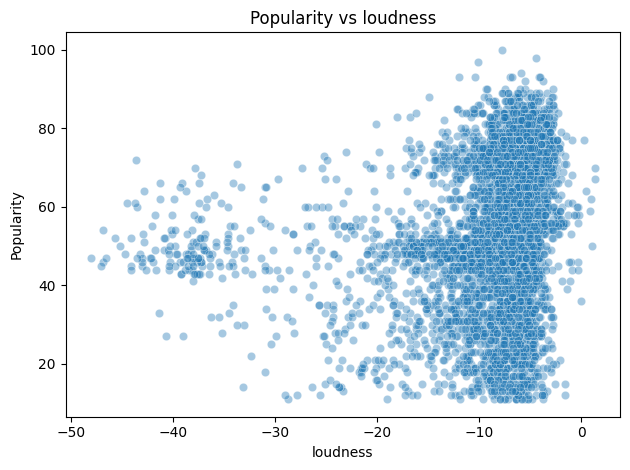

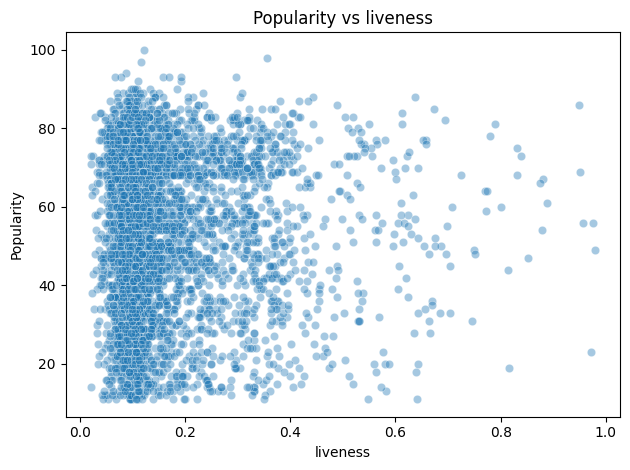

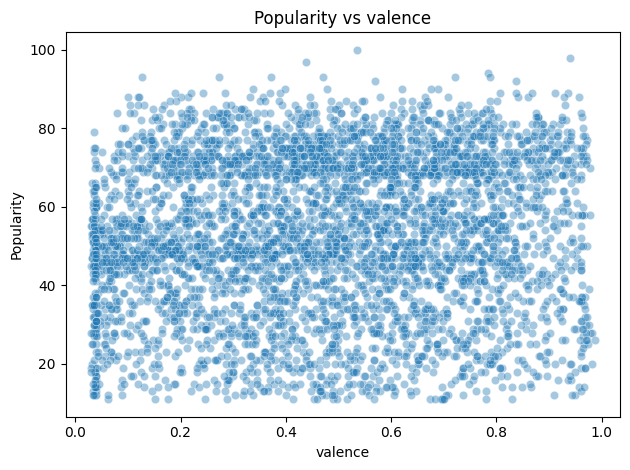

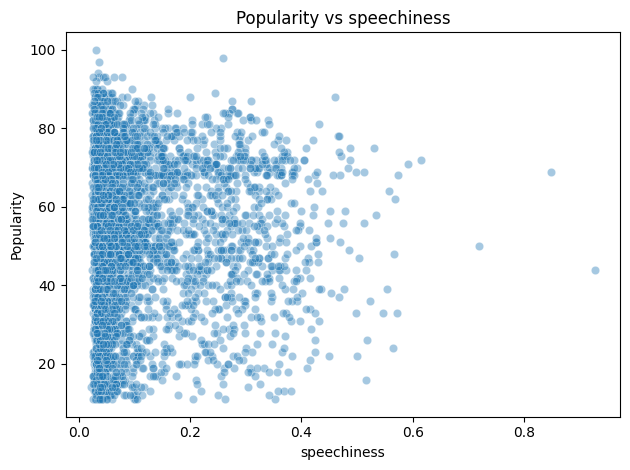

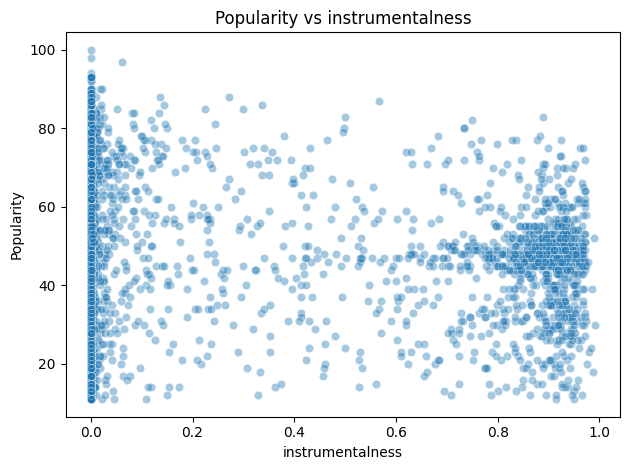

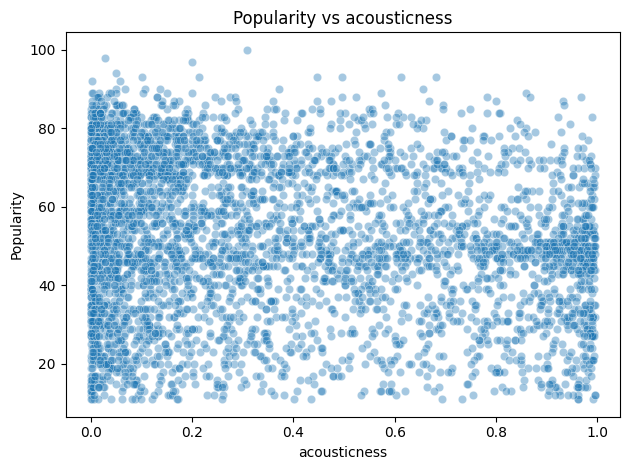

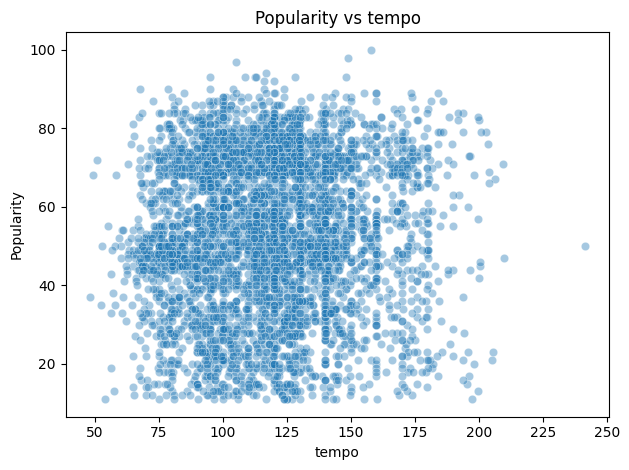

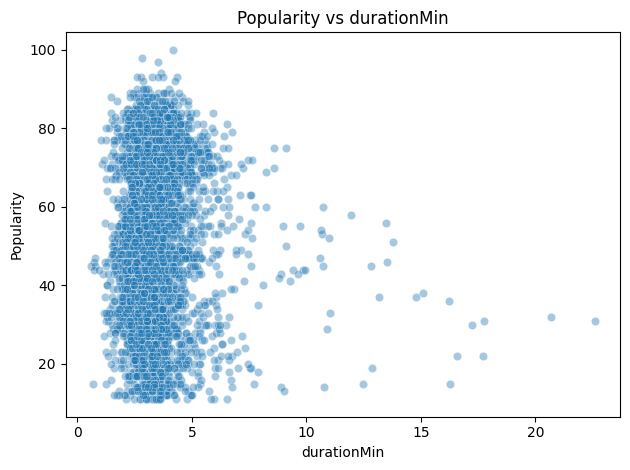

In [58]:
# Each audio feature vs popularity scatter plots
audioFeatures = ["energy", "danceability", "loudness", "liveness", "valence", "speechiness", "instrumentalness",
                 "acousticness", "tempo", "durationMin"]

for feature in audioFeatures:
    plt.figure()
    sns.scatterplot(data = df, x = feature, y = "popularity", alpha = 0.4)
    plt.title(f"Popularity vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Popularity")
    plt.tight_layout()
    plt.show()

No clear relationships can be seen between between audio features and popularity.

## Audio Features vs Popularity Groups

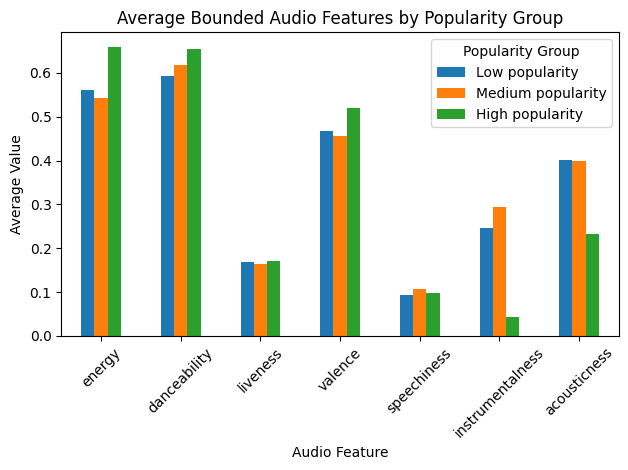

In [64]:
features = ["energy", "danceability", "liveness", "valence", "speechiness", "instrumentalness", "acousticness"]

featuresByPopularity = (df.groupby("popularityGroup")[features].mean()
                       .reindex(["Low popularity", "Medium popularity", "High popularity"]))

featuresByPopularity.T.plot(kind = "bar")

plt.title("Average Bounded Audio Features by Popularity Group")
plt.xlabel("Audio Feature")
plt.ylabel("Average Value")
plt.xticks(rotation = 45)
plt.legend(title = "Popularity Group")
plt.tight_layout()
plt.show()

High popularity is somewhat similar to other groups in terms of almost all the features, except for instrumentalness and acousticness. That indicates, that song with these high values aren't as popular.

# Saving the Dataset

In [69]:
# The dataset has been slightly modified, so saving the modified version to a new .csv file
df.to_csv(dataFolder + "/cleanDataWithGroups.csv", index = False)

## Key Takeaways


- the dataset is strongly skewed towards recent music - older songs are underrepresented
- popularity does not appear to have a strong simple relationship with most audio features - popularity is complex and probably depends on many factors beyond audio features
- highly popular tracks in this dataset tend to be less instrumental and less acoustic
- the clearest relationship is between loudness and energy - more energetic tracks are often louder
- older songs that remain in Spotify playlists may be more "durable", so they may have higher average popularity because only the successful older songs survive in the dataset